<a href="https://colab.research.google.com/github/Ingur-5967/ml-university/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%964_%D0%9C%D0%B5%D1%82%D0%BE%D0%B4_K_%D0%B1%D0%BB%D0%B8%D0%B6%D0%B0%D0%B9%D1%88%D0%B8%D1%85_%D1%81%D0%BE%D1%81%D0%B5%D0%B4%D0%B5%D0%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическая работа №4. Метод K-ближайших соседей

# Базовый алгоритм KNN

## KNN для классификации

### Получение данных

Будем работать с набором данным `iris` из `sklearn`.

In [3]:
from sklearn.datasets import load_iris
import pandas as pd

data = load_iris()

X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

print(X)
X

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


### 1. KNN из sklearn

#### 1.1. Разбейте данные на обучение и тест

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=10, test_size=20)

#### 1.2. Обучите модель KNN

In [11]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=4)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=4)

#### 1.3. Проверьте качество работы модели

In [13]:
from sklearn.metrics import accuracy_score

pred_test = model.predict(X_test)
display(accuracy_score(y_test, pred_test))

0.95

#### 1.4. Поэкспериментируйте с количеством соседей

1. Обучите модели с разным кол-вом соседей
2. Посчитайте метрику на тестовой выборке
3. Соберите данные в таблицу/график для наглядности
4. Выберите самое оптимальное значение $k$

In [14]:
scores = []
max_neighbors = 25

for k in range(1, max_neighbors+1):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    score = accuracy_score(y_test, model.predict(X_test))
    scores.append(score)

results = pd.DataFrame({'k': [i for i in range(1, max_neighbors+1)], 'Accuracy': scores})
results

,k,Accuracy
0,1,0.95
1,2,0.95
2,3,0.95
3,4,0.95
4,5,0.95
5,6,0.95
6,7,0.95
7,8,0.95
8,9,0.95
9,10,1.00


### 2. KNN рукописный

#### 2.1. Возьмите два случайных тестовых объектов

In [15]:
obj0_idx = 0
obj1_idx = 5
x1 = X_test.iloc[obj0_idx]
x2 = X_test.iloc[obj1_idx]
print(x2)
x2

sepal length (cm)    5.0
sepal width (cm)     2.0
petal length (cm)    3.5
petal width (cm)     1.0
Name: 60, dtype: float64


,60
sepal length (cm),5.0
sepal width (cm),2.0
petal length (cm),3.5
petal width (cm),1.0


#### 2.2. Посчитайте для каждого расстояния до всех объектов из обучения

In [18]:
import numpy as np
test_objects = [x1, x2]
distances_df = pd.DataFrame()
distances_df['Label'] = y_train
for i in range(len(test_objects)):
    sample = test_objects[i].values
    distance = np.linalg.norm(X_train.values - sample, axis=1, ord=2) # axis=1 для расчета по строкам
    distances_df[f'Test object {i} dst'] = distance
print(distances_df)
distances_df

     Label  Test object 0 dst  Test object 1 dst
0        2           2.004994           3.518522
1        2           1.584298           2.906888
2        2           0.818535           2.100000
3        0           3.304542           2.280351
4        1           0.854400           1.596872
..     ...                ...                ...
125      2           1.118034           1.997498
126      1           1.220656           1.126943
127      0           3.740321           3.257299
128      2           2.104757           3.629049
129      0           3.528456           2.455606

[130 rows x 3 columns]


,Label,Test object 0 dst,Test object 1 dst
0,2,2.004994,3.518522
1,2,1.584298,2.906888
2,2,0.818535,2.100000
3,0,3.304542,2.280351
4,1,0.854400,1.596872
...,...,...,...
125,2,1.118034,1.997498
126,1,1.220656,1.126943
127,0,3.740321,3.257299
128,2,2.104757,3.629049


#### 2.3. Выберите топ $k$ соседей для каждого объекта

In [19]:
k=10
display(distances_df.sort_values('Test object 0 dst').head(k))
display(distances_df.sort_values('Test object 1 dst').head(k))

,Label,Test object 0 dst,Test object 1 dst
30,1,0.264575,1.652271
111,1,0.591608,1.135782
115,1,0.608276,2.085665
11,1,0.616441,1.726268
82,1,0.616441,1.870829
121,1,0.624500,1.824829
76,1,0.670820,1.479865
10,1,0.700000,2.161018
98,2,0.707107,1.881489
33,1,0.707107,1.749286


,Label,Test object 0 dst,Test object 1 dst
89,1,1.729162,0.360555
93,1,1.808314,0.458258
32,1,1.109054,0.670820
77,1,1.024695,0.714143
43,1,1.865476,0.721110
106,1,0.905539,0.883176
97,1,0.916515,0.916515
22,1,1.276715,0.921954
57,1,1.161895,0.921954
126,1,1.220656,1.126943


#### 2.4. Выведите финальное предсказание для двух объектов основываясь на соседях

In [21]:
obj0 = distances_df.sort_values('Test object 0 dst').head(k)
obj1 = distances_df.sort_values('Test object 1 dst').head(k)
print(f"Предсказание 1: {obj0['Label'].value_counts().index[0]}")
print(f"Предсказание 2: {obj1['Label'].value_counts().index[0]}")

Предсказание 1: 1
Предсказание 2: 1


#### 2.5. Сравните с настоящими целевыми значениями этих двух объектов

In [24]:
print(f"Целевое значение для 1 объекта: {y_test[obj0_idx]}")
print(f"Целевое значение для 2 объекта: {y_test[obj1_idx]}")

Целевое значение для 1 объекта: 1
Целевое значение для 2 объекта: 1


## KNN для регрессии

### Получение данных


Будем работать с набором данных для задачи регрессии - данные по предсказанию стоимости недвижимости.

In [25]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np

data = fetch_california_housing()
X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

print(X)
X

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  
0        -122.23  
1

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


### KNN из sklearn

#### 3.1. Разбейте данные на обучение и тест

In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=10, test_size=10)

Затем нормализуйте данные:

In [28]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X_train)

X_train = pd.DataFrame(scaler.transform(X_train[X_train.columns]), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test[X_train.columns]), columns=X_train.columns)

#### 3.2. Обучите модель KNN


In [29]:
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=20)
model.fit(X_train, y_train)
pred_test = model.predict(X_test)

#### 3.3. Проверьте качество работы модели

In [31]:
from sklearn.metrics import r2_score

print(r2_score(y_test, pred_test))

0.659463124739666


#### 3.4. Поэкспериментируйте с количеством соседей

1. Обучите модели с разным кол-вом соседей
2. Посчитайте метрику на тестовой выборке
3. Соберите данные в таблицу/график для наглядности
4. Выберите самое оптимальное значение $k$

,k,R2 score
0,1,0.700158
1,2,0.303141
2,3,0.063961
3,4,0.170933
4,5,0.433847
...,...,...
70,71,0.620479
71,72,0.625853
72,73,0.631888
73,74,0.635691


None


<Axes: xlabel='k'>

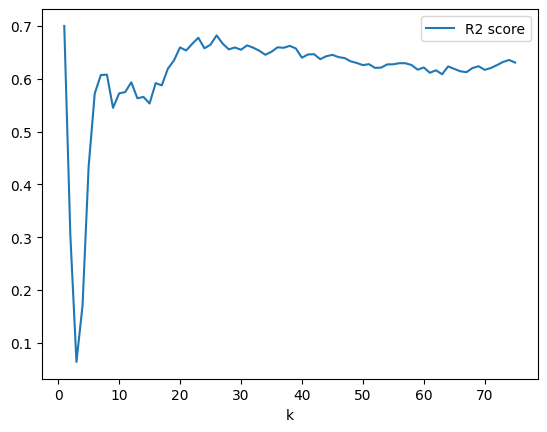

In [34]:
scores = []
k_range = 75

for k in range(1, k_range+1):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    score = r2_score(y_test, model.predict(X_test))
    scores.append(score)

results = pd.DataFrame({'k': [i for i in range(1, k_range+1)], 'R2 score': scores})
print(display(results))
results.plot(x='k', y='R2 score')

### 4. KNN рукописный

#### 4.1. Возьмите два случайных тестовых объектов

In [37]:
obj0_idx = 0
obj1_idx = 5
x1 = X_test.iloc[obj0_idx]
x2 = X_test.iloc[obj1_idx]
print(x2)
x2

MedInc        0.176315
HouseAge      0.254902
AveRooms      0.034381
AveBedrms     0.021854
Population    0.110681
AveOccup      0.001600
Latitude      0.651435
Longitude     0.352590
Name: 5, dtype: float64


,5
MedInc,0.176315
HouseAge,0.254902
AveRooms,0.034381
AveBedrms,0.021854
Population,0.110681
AveOccup,0.001600
Latitude,0.651435
Longitude,0.352590


#### 4.2. Посчитайте для каждого расстояния до всех объектов из обучения

In [39]:
test_objects = [x1, x2]
distances_df = pd.DataFrame()
distances_df['Label'] = y_train

for i in range(len(test_objects)):
    sample = test_objects[i].values
    distance = np.linalg.norm(X_train.values - sample, axis=1, ord=2)
    distances_df[f'Test object {i} dst'] = distance

print(distances_df)
distances_df

         Label  Test object 0 dst  Test object 1 dst
0      1.37800           0.857932           0.638189
1      5.00001           0.303979           0.588821
2      1.57900           0.663307           0.843223
3      1.09400           0.542096           0.102949
4      0.88900           0.311553           0.248831
...        ...                ...                ...
20625  3.10300           0.720094           0.502931
20626  2.55000           0.322818           0.584092
20627  2.41900           0.443768           0.294047
20628  1.50000           0.510065           0.700286
20629  1.91100           0.472559           0.197509

[20630 rows x 3 columns]


,Label,Test object 0 dst,Test object 1 dst
0,1.37800,0.857932,0.638189
1,5.00001,0.303979,0.588821
2,1.57900,0.663307,0.843223
3,1.09400,0.542096,0.102949
4,0.88900,0.311553,0.248831
...,...,...,...
20625,3.10300,0.720094,0.502931
20626,2.55000,0.322818,0.584092
20627,2.41900,0.443768,0.294047
20628,1.50000,0.510065,0.700286


#### 4.3. Выберите топ $k$ соседей для каждого объекта

In [41]:
k=5
display(distances_df.sort_values('Test object 0 dst').head(k))
display(distances_df.sort_values('Test object 1 dst').head(k))

,Label,Test object 0 dst,Test object 1 dst
2947,2.750,0.029117,0.543408
16352,3.190,0.063238,0.534329
19415,3.138,0.065230,0.541692
6744,2.641,0.065778,0.526794
1373,2.356,0.069493,0.548612


,Label,Test object 0 dst,Test object 1 dst
12147,1.468,0.558264,0.060581
11823,1.129,0.553272,0.060875
11338,1.273,0.561940,0.065706
5515,1.244,0.563577,0.068861
698,1.044,0.539464,0.071518


#### 4.4. Выведите финальное предсказание для двух объектов основываясь на соседях

In [42]:
obj0 = distances_df.sort_values('Test object 0 dst').head(k)
obj1 = distances_df.sort_values('Test object 1 dst').head(k)
print(f"Предсказание для 1 объекта: {obj0['Label'].median()}")
print(f"Предсказание для 2 объекта: {obj1['Label'].median()}")

Предсказание для 1 объекта: 2.75
Предсказание для 2 объекта: 1.244


#### 4.5. Сравните с настоящими целевыми значениями этих двух объектов

In [43]:
print(f"Целевое значение для первого объекта: {y_test[obj0_idx]}")
print(f"Целевое значение для второго объекта: {y_test[obj1_idx]}")

Целевое значение для первого объекта: 1.674
Целевое значение для второго объекта: 1.188


Предсказания отклоняются от истины, но не так сильно, они довольно близки.

# Weighted KNN

## KNN для классификации

### Получение данных

Будем работать с набором данным `iris` из `sklearn`.

In [46]:
from sklearn.datasets import load_iris
import pandas as pd

data = load_iris()

X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

print(X.head())
X.head()

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### Выберите только 0 и 3 признак (sepal length (cm) и petal width (cm))

In [50]:
df = X[['sepal length (cm)', 'petal width (cm)']]
print(df)
df

     sepal length (cm)  petal width (cm)
0                  5.1               0.2
1                  4.9               0.2
2                  4.7               0.2
3                  4.6               0.2
4                  5.0               0.2
..                 ...               ...
145                6.7               2.3
146                6.3               1.9
147                6.5               2.0
148                6.2               2.3
149                5.9               1.8

[150 rows x 2 columns]


,sepal length (cm),petal width (cm)
0,5.1,0.2
1,4.9,0.2
2,4.7,0.2
3,4.6,0.2
4,5.0,0.2
...,...,...
145,6.7,2.3
146,6.3,1.9
147,6.5,2.0
148,6.2,2.3


### Визуализируйте ваши данные на графике

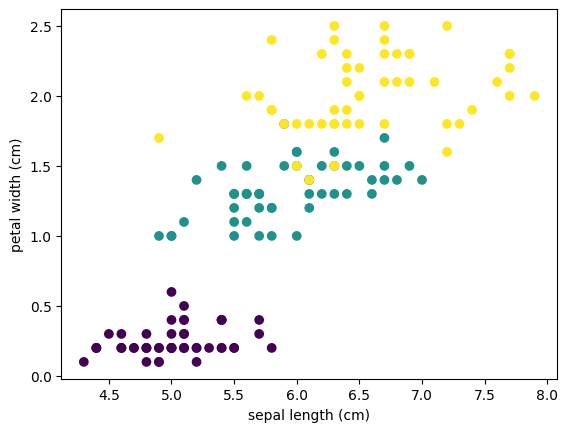

In [52]:
import matplotlib.pyplot as plt

plt.scatter(df['sepal length (cm)'], df['petal width (cm)'], c=y)
plt.xlabel('sepal length (cm)')
plt.ylabel('petal width (cm)')
plt.show()

### 1. KNN из sklearn

#### 1.1. Разбейте данные на обучение и тест

In [53]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df, y, random_state=10, test_size=10)

#### 1.2. Обучите модель KNN на 50 соседях

In [54]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=50)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=50)

#### 1.3. Проверьте качество работы модели

In [56]:
from sklearn.metrics import accuracy_score
pred_test = model.predict(X_test)
print(display(accuracy_score(y_test, pred_test)))
print(display(y_test, pred_test))

0.9

None


array([1, 2, 0, 1, 0, 1, 1, 1, 0, 1])

array([1, 2, 0, 1, 0, 0, 1, 1, 0, 1])

None


#### 1.4. Возьмите один случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [57]:
import numpy as np
obj0_idx = 0
x1 = X_test.iloc[obj0_idx]
distances_df = pd.DataFrame()
distances_df['Label'] = y_train
sample = x1.values
distance = np.linalg.norm(X_train.values - sample, axis=1, ord=2)
distances_df['Test object 0 dst'] = distance
distances_df

,Label,Test object 0 dst
0,1,0.728011
1,2,0.781025
2,1,0.800000
3,0,1.780449
4,0,1.562050
...,...,...
135,2,0.921954
136,1,0.700000
137,0,1.081665
138,2,1.029563


#### 1.5. Выберите топ  k  соседей


In [59]:
k=15
display(distances_df.sort_values('Test object 0 dst').head(k))

,Label,Test object 0 dst
21,1,0.100000
92,1,0.100000
65,2,0.200000
86,1,0.200000
40,1,0.223607
91,2,0.223607
47,1,0.223607
44,1,0.223607
131,1,0.223607
125,1,0.282843


#### 1.6. Выведите финальное предсказание для этого объекта

In [60]:
obj0 = distances_df.sort_values('Test object 0 dst').head(k)
print(f"Предсказание для объекта: {obj0['Label'].value_counts().index[0]}")

Предсказание для объекта: 1


#### 1.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [61]:
print(f"Целевое значение для объекта: {y_test[obj0_idx]}")
print(f"Предсказанное целевое значение для объекта: {model.predict(X_test)[obj0_idx]}")

Целевое значение для объекта: 1
Предсказанное целевое значение для объекта: 1


#### 1.8 Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей

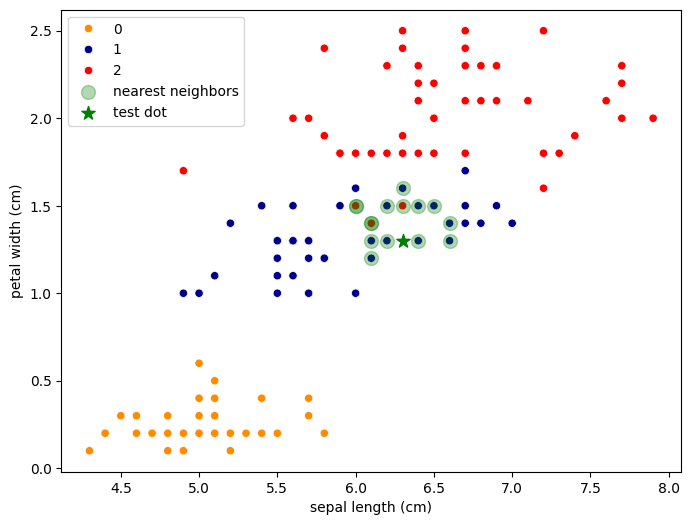

In [63]:
import seaborn as sns

nearest_neigbors_idxs = distances_df.sort_values('Test object 0 dst').head(k).index

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_train['sepal length (cm)'],
    y=X_train['petal width (cm)'],
    hue=y_train,
    palette=["darkorange", "darkblue", "red"]
)

plt.scatter(X_train.iloc[nearest_neigbors_idxs]['sepal length (cm)'], X_train.iloc[nearest_neigbors_idxs]['petal width (cm)'],
            c='g', alpha=0.3, marker='o', s=100, label='nearest neighbors')

plt.scatter(X_test.iloc[obj0_idx]['sepal length (cm)'], X_test.iloc[obj0_idx]['petal width (cm)'], c='g', marker='*', s=100, label='test dot')
plt.legend()

### 2. Weighted KNN

#### 2.1. Обучите модель "взвешенный KNN" по дистанции

In [64]:
model = KNeighborsClassifier(n_neighbors=50, weights='distance')
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=50, weights='distance')

#### 2.2. Проверьте качество работы модели


In [66]:
from sklearn.metrics import accuracy_score
pred_test = model.predict(X_test)
print(display(accuracy_score(y_test, pred_test)))
print(display(y_test, pred_test))

0.9

array([1, 2, 0, 1, 0, 1, 1, 1, 0, 1])

array([1, 2, 0, 1, 0, 1, 2, 1, 0, 1])

#### 2.3. Возьмите тот же случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [68]:
import numpy as np
obj0_idx = 0
x1 = X_test.iloc[obj0_idx]
distances_df = pd.DataFrame()
distances_df['Label'] = y_train
sample = x1.values
distance = np.linalg.norm(X_train.values - sample, axis=1, ord=2)
distances_df[f'Test object 0 dst'] = distance
print(distances_df)
distances_df

     Label  Test object 0 dst
0        1           0.728011
1        2           0.781025
2        1           0.800000
3        0           1.780449
4        0           1.562050
..     ...                ...
135      2           0.921954
136      1           0.700000
137      0           1.081665
138      2           1.029563
139      0           1.843909

[140 rows x 2 columns]


,Label,Test object 0 dst
0,1,0.728011
1,2,0.781025
2,1,0.800000
3,0,1.780449
4,0,1.562050
...,...,...
135,2,0.921954
136,1,0.700000
137,0,1.081665
138,2,1.029563


#### 2.4. Выберите топ  k  соседей


In [69]:
k=15
display(distances_df.sort_values('Test object 0 dst').head(k))

,Label,Test object 0 dst
21,1,0.100000
92,1,0.100000
65,2,0.200000
86,1,0.200000
40,1,0.223607
91,2,0.223607
47,1,0.223607
44,1,0.223607
131,1,0.223607
125,1,0.282843


#### 2.5. Рассчитайте вес для каждого соседа

In [71]:
distances_df['weight'] = 1 / distances_df['Test object 0 dst']
print(distances_df)
distances_df

     Label  Test object 0 dst    weight
0        1           0.728011  1.373606
1        2           0.781025  1.280369
2        1           0.800000  1.250000
3        0           1.780449  0.561656
4        0           1.562050  0.640184
..     ...                ...       ...
135      2           0.921954  1.084652
136      1           0.700000  1.428571
137      0           1.081665  0.924500
138      2           1.029563  0.971286
139      0           1.843909  0.542326

[140 rows x 3 columns]


,Label,Test object 0 dst,weight
0,1,0.728011,1.373606
1,2,0.781025,1.280369
2,1,0.800000,1.250000
3,0,1.780449,0.561656
4,0,1.562050,0.640184
...,...,...,...
135,2,0.921954,1.084652
136,1,0.700000,1.428571
137,0,1.081665,0.924500
138,2,1.029563,0.971286


#### 2.6. Выведите финальное предсказание для этого объекта

In [72]:
display(f"Вес для класса 0 - {distances_df[distances_df['Label'] == 0]['weight'].sum()}",
        f"Вес для класса 1 - {distances_df[distances_df['Label'] == 1]['weight'].sum()}",
        f"Вес для класса 2 - {distances_df[distances_df['Label'] == 2]['weight'].sum()}")

'Вес для класса 0 - 28.712837854932715'

'Вес для класса 1 - 109.08778843949642'

'Вес для класса 2 - 63.725176242643386'

#### 2.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [73]:
print(f"Целевое значение для объекта: {y_test[obj0_idx]}")
print(f"Предсказанное целевое значение для объекта: {model.predict(X_test)[obj0_idx]}")

Целевое значение для объекта: 1
Предсказанное целевое значение для объекта: 1


#### 2.8. Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей по удаленности

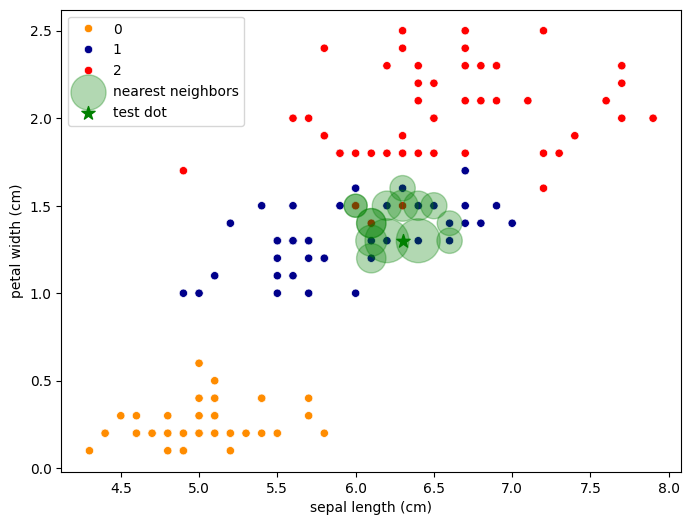

In [74]:
import seaborn as sns

nearest_neigbors_idxs = distances_df.sort_values('Test object 0 dst').head(k).index

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_train["sepal length (cm)"],
    y=X_train["petal width (cm)"],
    hue=y_train,
    palette=["darkorange", "darkblue", "red"]
)

plt.scatter(X_train['sepal length (cm)'].iloc[nearest_neigbors_idxs], X_train['petal width (cm)'].iloc[nearest_neigbors_idxs],
            c='g', alpha=0.3, marker='o', s=distances_df['weight'].iloc[nearest_neigbors_idxs]*100, label='nearest neighbors')

plt.scatter(X_test['sepal length (cm)'].iloc[obj0_idx], X_test['petal width (cm)'].iloc[obj0_idx], c='g', marker='*', s=100, label='test dot')
plt.legend()

### 3. Еще одна задача классификации

### Получение данных

Будем работать с набором данным `fetch_olivetti_faces` из `sklearn`.

In [76]:
from sklearn.datasets import fetch_olivetti_faces
import pandas as pd

data = fetch_olivetti_faces(shuffle=True, random_state=9)

X = pd.DataFrame(data['data'])
y = data['target']

print(X.head())

X.head()

       0         1         2         3         4         5         6     \
0  0.723140  0.710744  0.714876  0.731405  0.735537  0.752066  0.772727   
1  0.289256  0.157025  0.148760  0.190083  0.169421  0.194215  0.404959   
2  0.586777  0.595041  0.681818  0.694215  0.714876  0.698347  0.714876   
3  0.235537  0.351240  0.479339  0.545455  0.566116  0.566116  0.595041   
4  0.318182  0.400826  0.491736  0.528926  0.586777  0.657025  0.681818   

       7         8         9     ...      4086      4087      4088      4089  \
0  0.793388  0.814050  0.834711  ...  0.793388  0.904959  0.549587  0.409091   
1  0.607438  0.669421  0.677686  ...  0.438017  0.400826  0.421488  0.429752   
2  0.727273  0.743802  0.739669  ...  0.495868  0.380165  0.400826  0.330579   
3  0.607438  0.619835  0.623967  ...  0.169421  0.198347  0.202479  0.214876   
4  0.685950  0.702479  0.698347  ...  0.074380  0.132231  0.181818  0.136364   

       4090      4091      4092      4093      4094      4095  
0  0

,0,1,2,3,4,5,6,7,8,9,...,4086,4087,4088,4089,4090,4091,4092,4093,4094,4095
0,0.723140,0.710744,0.714876,0.731405,0.735537,0.752066,0.772727,0.793388,0.814050,0.834711,...,0.793388,0.904959,0.549587,0.409091,0.491736,0.487603,0.471074,0.483471,0.475207,0.475207
1,0.289256,0.157025,0.148760,0.190083,0.169421,0.194215,0.404959,0.607438,0.669421,0.677686,...,0.438017,0.400826,0.421488,0.429752,0.433884,0.425620,0.438017,0.438017,0.210744,0.206612
2,0.586777,0.595041,0.681818,0.694215,0.714876,0.698347,0.714876,0.727273,0.743802,0.739669,...,0.495868,0.380165,0.400826,0.330579,0.148760,0.119835,0.123967,0.115702,0.119835,0.107438
3,0.235537,0.351240,0.479339,0.545455,0.566116,0.566116,0.595041,0.607438,0.619835,0.623967,...,0.169421,0.198347,0.202479,0.214876,0.202479,0.214876,0.214876,0.214876,0.210744,0.206612
4,0.318182,0.400826,0.491736,0.528926,0.586777,0.657025,0.681818,0.685950,0.702479,0.698347,...,0.074380,0.132231,0.181818,0.136364,0.128099,0.148760,0.144628,0.140496,0.148760,0.152893


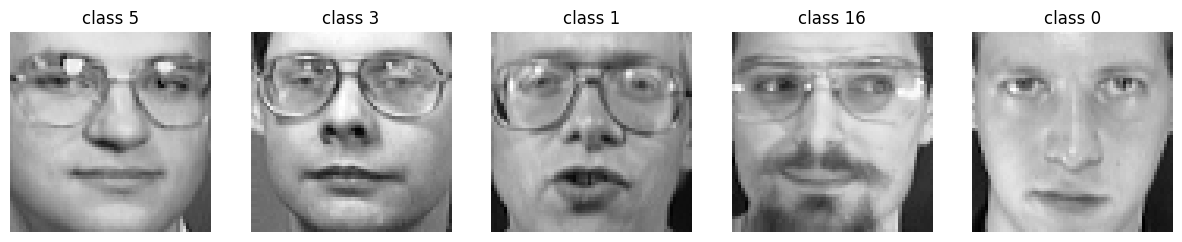

In [79]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 5, figsize=(15, 8))

for i in range(0, 5):
    ax[i].imshow(X.iloc[i].values.reshape((64, 64)), cmap='gray')
    ax[i].axis('off')
    ax[i].set_title(f'class {y[i]}')

plt.show()

### 3.1. KNN из sklearn

#### 3.1.1. Разбейте данные на обучение и тест

In [80]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=10, test_size=30)
X_train.shape, X_test.shape

((370, 4096), (30, 4096))

#### 3.1.2. Обучите модель KNN на 50 соседях

In [81]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=50)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=50)

#### 3.1.3. Проверьте качество работы модели


In [82]:
from sklearn.metrics import accuracy_score
pred_test = model.predict(X_test)
print(display(accuracy_score(y_test, pred_test)))
print(display(y_test, pred_test))

0.26666666666666666

None


array([16, 38, 12,  2, 13, 12, 10, 16, 12,  6, 19, 37, 22, 32, 31, 28, 30,
        1, 32, 24,  9,  0, 33, 11, 36,  3, 15, 21, 29, 34])

array([ 4, 21, 17,  4, 13, 24, 10, 24,  4, 17, 29,  4, 17, 20, 31, 28, 20,
        1, 38,  4, 17, 37, 33, 24, 20, 17, 17, 21, 29,  4])

None


### 3.2. Weighted KNN

#### 3.2.1. Обучите модель взвешенный KNN по дистанции

In [83]:
model = KNeighborsClassifier(n_neighbors=50, weights='distance')
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=50, weights='distance')

#### 3.2.2. Проверьте качество работы модели


In [85]:
pred_test = model.predict(X_test)
print(display(accuracy_score(y_test, pred_test)))
print(display(y_test, pred_test))

0.4666666666666667

None


array([16, 38, 12,  2, 13, 12, 10, 16, 12,  6, 19, 37, 22, 32, 31, 28, 30,
        1, 32, 24,  9,  0, 33, 11, 36,  3, 15, 21, 29, 34])

array([ 4, 38, 17,  4, 13, 24, 10, 24, 12, 17, 29,  4, 22, 32, 31, 28, 20,
        1, 32,  4, 17, 37, 33, 24, 36, 17, 17, 21, 29, 39])

None


### 3.3. Custom Weighted KNN

#### 3.3.1. Напишите свою функцию подсчета весов по дистанции

(Можете выбрать любой подход)

In [86]:
def count_dist(dists):
  return 1/dists

#### 3.3.2. Обучите модель взвешенный KNN по написанной функции выше

In [88]:
model = KNeighborsClassifier(n_neighbors=50, weights=count_dist)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=50,
                     weights=<function count_dist at 0x7c737ba74680>)

#### 3.3.3. Проверьте качество работы модели


In [90]:
pred_test = model.predict(X_test)
print(display(accuracy_score(y_test, pred_test)))
print(display(y_test, pred_test))

0.4666666666666667

None


array([16, 38, 12,  2, 13, 12, 10, 16, 12,  6, 19, 37, 22, 32, 31, 28, 30,
        1, 32, 24,  9,  0, 33, 11, 36,  3, 15, 21, 29, 34])

array([ 4, 38, 17,  4, 13, 24, 10, 24, 12, 17, 29,  4, 22, 32, 31, 28, 20,
        1, 32,  4, 17, 37, 33, 24, 36, 17, 17, 21, 29, 39])

None


## KNN для регрессии

### Получение данных


Будем работать с набором данных для задачи регрессии - данные по предсказанию стоимости недвижимости.

In [91]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
data = fetch_california_housing()
X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

print(X)
X

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  
0        -122.23  
1

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


### Возьмите только признак MedInc и 1000 первых строк

In [92]:
Xset = pd.DataFrame(X['MedInc'][:1000])
yset = y[:1000]

### Отрисуйте данные на графике

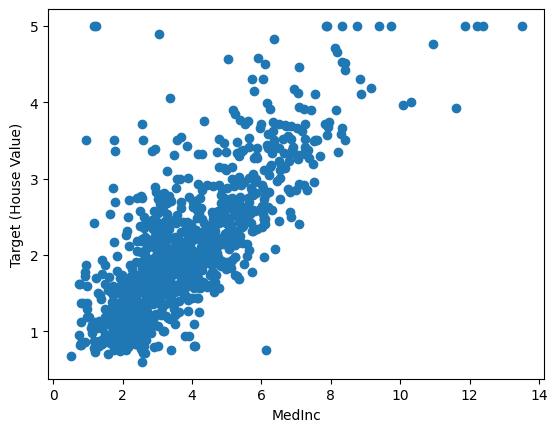

In [93]:
import matplotlib.pyplot as plt

plt.scatter(Xset, yset)
plt.xlabel('MedInc')
plt.ylabel('Target (House Value)')
plt.show()

### 4. KNN из sklearn

#### 4.1. Разбейте данные на обучение и тест

In [94]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(Xset, yset, random_state=10, test_size=100)
X_train.shape, X_test.shape

((900, 1), (100, 1))

#### 4.2. Обучите модель KNN на 100 соседях


In [95]:
from sklearn.neighbors import KNeighborsRegressor
model = KNeighborsRegressor(n_neighbors=100)
model.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=100)

#### 4.3. Проверьте качество работы модели


In [97]:
from sklearn.metrics import r2_score
pred_test = model.predict(X_test)
print(display(r2_score(y_test, pred_test)))

0.7373856697004726

None


#### 4.4. Возьмите один случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [98]:
import numpy as np
obj0_idx = 0
x1 = X_test.iloc[obj0_idx]
distances_df = pd.DataFrame()
distances_df['Label'] = y_train
sample = x1.values
distance = np.linalg.norm(X_train.values - sample, axis=1, ord=2)
distances_df['Test object 0 dst'] = distance
print(distances_df)
distances_df

     Label  Test object 0 dst
0    3.235             2.5501
1    1.981             1.3447
2    1.703             1.0554
3    2.359             1.6152
4    1.964             0.1450
..     ...                ...
895  0.818             3.4338
896  2.102             1.0579
897  4.188             4.9181
898  3.373             1.2220
899  1.600             1.3600

[900 rows x 2 columns]


,Label,Test object 0 dst
0,3.235,2.5501
1,1.981,1.3447
2,1.703,1.0554
3,2.359,1.6152
4,1.964,0.1450
...,...,...
895,0.818,3.4338
896,2.102,1.0579
897,4.188,4.9181
898,3.373,1.2220


#### 4.5. Выберите топ  k  соседей


In [99]:
k=15
display(distances_df.sort_values('Test object 0 dst').head(k))

,Label,Test object 0 dst
317,1.923,0.0036
325,2.060,0.0069
689,2.750,0.0090
526,2.212,0.0118
773,1.926,0.0150
441,2.613,0.0264
515,1.250,0.0267
890,2.103,0.0320
185,1.793,0.0376
342,2.469,0.0377


#### 4.6. Выведите финальное предсказание для этого объекта

In [100]:
obj0 = distances_df.sort_values('Test object 0 dst').head(k)
print(f"Предсказание для 1 объекта: {obj0['Label'].median()}")

Предсказание для 1 объекта: 2.212


#### 4.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [101]:
print(f"Целевое значение для объекта: {y_test[obj0_idx]}")
print(f"Предсказанное целевое значение для объекта: {model.predict(X_test)[obj0_idx]}")

Целевое значение для объекта: 1.563
Предсказанное целевое значение для объекта: 2.05415


#### 4.8 Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей

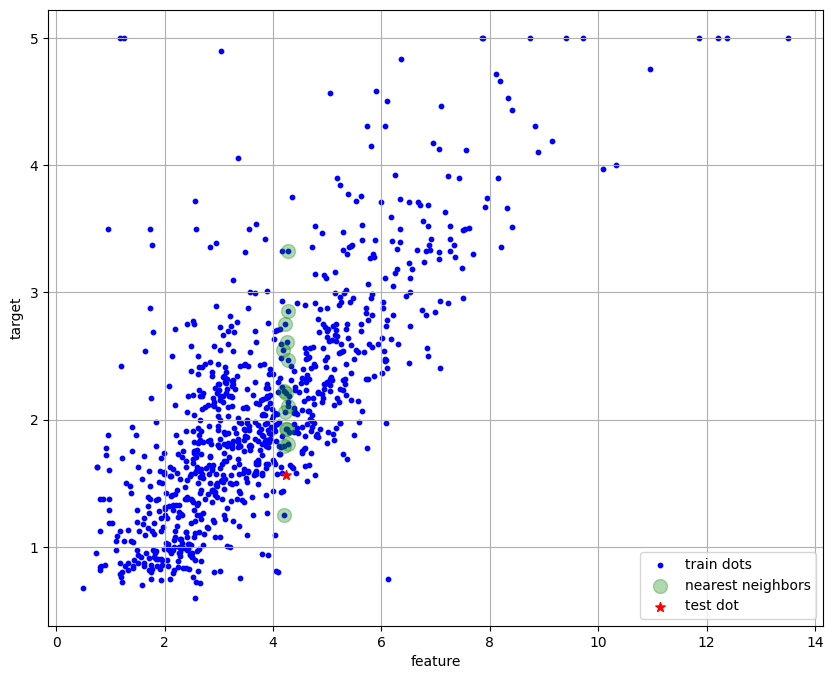

In [102]:
import matplotlib.pyplot as plt

nearest_neigbors_idxs = distances_df.sort_values('Test object 0 dst').head(k).index
plt.figure(figsize=(10, 8))

plt.scatter(X_train, y_train, c='b', marker='o', s=10, label='train dots')
plt.scatter(X_train.iloc[nearest_neigbors_idxs], y_train[nearest_neigbors_idxs],
            c='g', alpha=0.3, marker='o', s=100, label='nearest neighbors')
plt.scatter(X_test.iloc[obj0_idx], y_test[obj0_idx], c='r', marker='*', s=50, label='test dot')
plt.grid()
plt.ylabel('target')
plt.xlabel('feature')
plt.legend()

### 5. Weighted KNN

#### 5.1. Обучите модель взвешенный KNN по дистанции

In [103]:
from sklearn.neighbors import KNeighborsRegressor
model = KNeighborsRegressor(n_neighbors=100, weights='distance')
model.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=100, weights='distance')

#### 5.2. Проверьте качество работы модели

In [106]:
from sklearn.metrics import r2_score
pred_test = model.predict(X_test)
print(display(r2_score(y_test, pred_test)))

0.6878337357233759

None


#### 5.3. Возьмите тот же случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [108]:
import numpy as np
obj0_idx = 0
x1 = X_test.iloc[obj0_idx]
distances_df = pd.DataFrame()
distances_df['Label'] = y_train
sample = x1.values
distance = np.linalg.norm(X_train.values - sample, axis=1, ord=2)
distances_df[f'Test object 0 dst'] = distance
print(distances_df)
distances_df

     Label  Test object 0 dst
0    3.235             2.5501
1    1.981             1.3447
2    1.703             1.0554
3    2.359             1.6152
4    1.964             0.1450
..     ...                ...
895  0.818             3.4338
896  2.102             1.0579
897  4.188             4.9181
898  3.373             1.2220
899  1.600             1.3600

[900 rows x 2 columns]


,Label,Test object 0 dst
0,3.235,2.5501
1,1.981,1.3447
2,1.703,1.0554
3,2.359,1.6152
4,1.964,0.1450
...,...,...
895,0.818,3.4338
896,2.102,1.0579
897,4.188,4.9181
898,3.373,1.2220


#### 5.4. Выберите топ  k  соседей

In [110]:
k=15
display(distances_df.sort_values('Test object 0 dst').head(k))

,Label,Test object 0 dst
317,1.923,0.0036
325,2.060,0.0069
689,2.750,0.0090
526,2.212,0.0118
773,1.926,0.0150
441,2.613,0.0264
515,1.250,0.0267
890,2.103,0.0320
185,1.793,0.0376
342,2.469,0.0377


#### 5.5. Рассчитайте вес для каждого соседа

In [111]:
distances_df['weight'] = 1 / distances_df['Test object 0 dst']
print(distances_df)
distances_df

     Label  Test object 0 dst    weight
0    3.235             2.5501  0.392141
1    1.981             1.3447  0.743660
2    1.703             1.0554  0.947508
3    2.359             1.6152  0.619118
4    1.964             0.1450  6.896552
..     ...                ...       ...
895  0.818             3.4338  0.291223
896  2.102             1.0579  0.945269
897  4.188             4.9181  0.203331
898  3.373             1.2220  0.818331
899  1.600             1.3600  0.735294

[900 rows x 3 columns]


,Label,Test object 0 dst,weight
0,3.235,2.5501,0.392141
1,1.981,1.3447,0.743660
2,1.703,1.0554,0.947508
3,2.359,1.6152,0.619118
4,1.964,0.1450,6.896552
...,...,...,...
895,0.818,3.4338,0.291223
896,2.102,1.0579,0.945269
897,4.188,4.9181,0.203331
898,3.373,1.2220,0.818331


#### 5.6. Выведите финальное предсказание для этого объекта

In [112]:
print((distances_df['Label'] * distances_df['weight']).sum() / distances_df['weight'].sum())

2.108126141442349


#### 5.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [113]:
print(f"Целевое значение для объекта: {y_test[obj0_idx]}")
print(f"Предсказанное целевое значение для объекта: {model.predict(X_test)[obj0_idx]}")

Целевое значение для объекта: 1.563
Предсказанное целевое значение для объекта: 2.1149100650455326


#### 5.8. Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей по удаленности

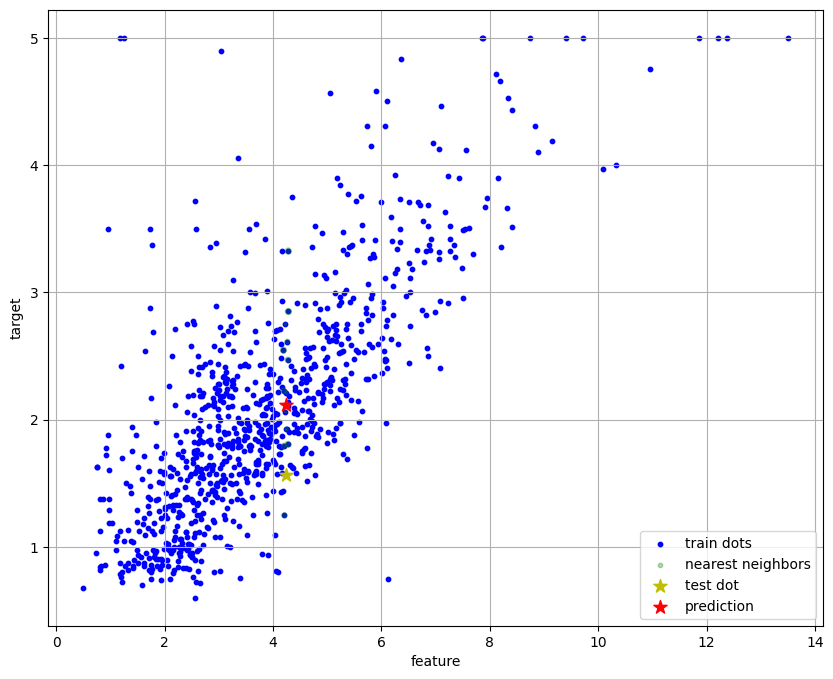

In [115]:
plt.figure(figsize=(10, 8))
nearest_neigbors_idxs = distances_df.sort_values('Test object 0 dst').head(k).index

plt.scatter(X_train, y_train, c='b', marker='o', s=10, label='train dots')
plt.grid()

plt.scatter(X_train.iloc[nearest_neigbors_idxs], y_train[nearest_neigbors_idxs],
            c='g', alpha=0.3, marker='o', s=distances_df['Test object 0 dst'].iloc[nearest_neigbors_idxs]*400, label='nearest neighbors')

plt.scatter(X_test['MedInc'].iloc[obj0_idx], y_test[obj0_idx], c='y', marker='*', s=100, label='test dot')
plt.scatter(X_test['MedInc'].iloc[obj0_idx], pred_test[obj0_idx], c='r', marker='*', s=100, label='prediction')

plt.xlabel('feature')
plt.ylabel('target')

plt.legend()

## 6. Еще одна задача регрессии

### Получение данных

Будем работать с тем же самым набором данным `fetch_olivetti_faces` из `sklearn`, но уже для задачи регрессии - будем восстанавливать изображение.

In [116]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_olivetti_faces

data, _ = fetch_olivetti_faces(return_X_y=True)
train, test = train_test_split(data, test_size=0.2, random_state=4)

Поделим данные на X и y, где X - это верхняя часть лица человека, на этом модель будет обучаться, а y - это нижняя часть лица человека - её будем предсказывать.

In [118]:
n_pixels = data.shape[1]

X_train = train[:, :(n_pixels + 1) // 2]
y_train = train[:, n_pixels // 2:]

X_test = test[:, :(n_pixels + 1) // 2]
y_test = test[:, n_pixels // 2:]

Вот один пример обучающей пары.

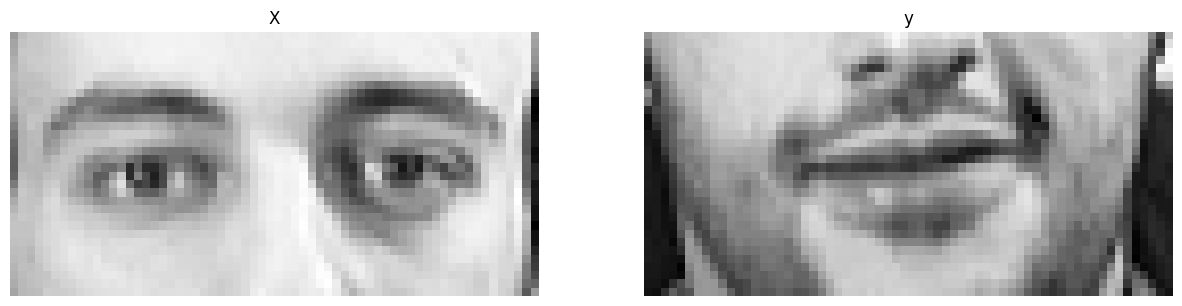

In [119]:
import matplotlib.pyplot as plt

idx = 0

fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].imshow(X_train[idx].reshape((32, 64)), cmap='gray')
ax[0].set_title('X')
ax[1].imshow(y_train[idx].reshape((32, 64)), cmap='gray')
ax[1].set_title('y')
ax[0].axis('off')
ax[1].axis('off')

plt.show()

#### 6.1. Обучите модель KNN и назовите переменную с моделью knn на 100 соседях

In [120]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=100)
knn.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=100)

#### 6.2. Проверьте качество работы модели

При этом предсказания модели запишите в словарь pred_test с ключом knn.


In [121]:
pred_test = {'knn': None,
             'weighted_knn': None,
             'weighted_knn_custom': None}

In [123]:
from sklearn.metrics import r2_score

pred_test = {'knn': knn.predict(X_test),
             'weighted_knn': None,
             'weighted_knn_custom': None}
print(display(r2_score(y_test, pred_test['knn'])))

0.21050623059272766

None


#### 6.3. Обучите модель KNN с весами по дистанции и назовите переменную с моделью weighted_knn на 100 соседях

In [124]:
weighted_knn = KNeighborsRegressor(n_neighbors=100, weights='distance')
weighted_knn.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=100, weights='distance')

#### 6.4. Проверьте качество работы модели

При этом предсказания модели запишите в словарь pred_test с ключом weighted_knn.


In [125]:
pred_test['weighted_knn'] = weighted_knn.predict(X_test)
print(display(r2_score(y_test, pred_test['weighted_knn'])))

0.24241627640538166

None


#### 6.5. Напишите свою функцию подсчета весов по дистанции

(Можете выбрать любой подход)


In [126]:
def count_dist(dists):
  return 1/dists

#### 6.6. Обучите модель KNN с кастомными весами по дистанции и назовите переменную с моделью weighted_knn_custom на 100 соседях

In [127]:
weighted_knn_custom = KNeighborsRegressor(n_neighbors=100, weights=count_dist)
weighted_knn_custom.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=100,
                    weights=<function count_dist at 0x7c737b8e11c0>)

#### 6.7. Проверьте качество работы модели

При этом предсказания модели запишите в словарь pred_test с ключом weighted_knn_custom.


In [129]:
pred_test['weighted_knn_custom'] = weighted_knn_custom.predict(X_test)
print(display(r2_score(y_test, pred_test['weighted_knn_custom'])))

0.24241627640538166

None


А сейчас отрисуем все предсказания.

In [130]:
ESTIMATORS = {'knn': knn,
              'weighted_knn': weighted_knn,
              'weighted_knn_custom': weighted_knn_custom}

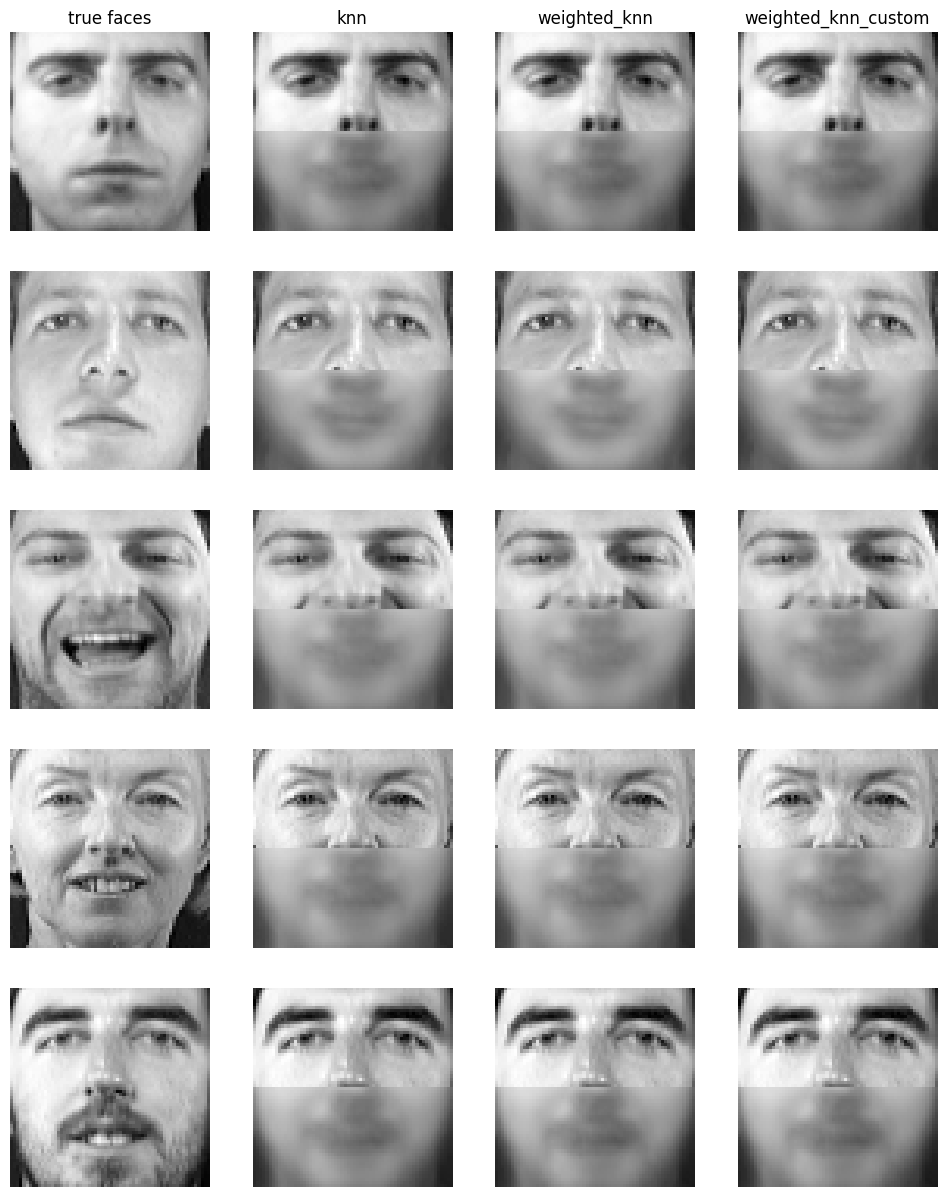

In [131]:
n_faces = 5
n_cols = 1 + len(ESTIMATORS)
image_shape = (64, 64)
plt.figure(figsize=(3 * n_cols, 3 * n_faces))

for i in range(5):
    true_face = np.hstack((X_test[i], y_test[i]))

    if i:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 1)
    else:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 1, title="true faces")

    sub.axis("off")
    sub.imshow(
        true_face.reshape(image_shape), cmap=plt.cm.gray, interpolation="nearest"
    )

    for j, est in enumerate(sorted(ESTIMATORS)):
        completed_face = np.hstack((X_test[i], pred_test[est][i]))

        if i:
            sub = plt.subplot(n_faces, n_cols, i * n_cols + 2 + j)

        else:
            sub = plt.subplot(n_faces, n_cols, i * n_cols + 2 + j, title=est)

        sub.axis("off")
        sub.imshow(
            completed_face.reshape(image_shape),
            cmap=plt.cm.gray,
            interpolation="nearest",
        )

#### 7*. Подберите лучшие гиперпараметры для модели, используя метод [GridSearchCV](https://scikit-learn.org/stable/modules/grid_search.html)

Примеры использования можно найти в технической документации, предыдущей работе, а также в следующих источниках:

[Пример 1](https://machinelearningknowledge.ai/knn-classifier-in-sklearn-using-gridsearchcv-with-example/#vii_Model_fitting_with_K-cross_Validation_and_GridSearchCV)


[Пример 2](https://vc.ru/ml/147132-kak-avtomaticheski-podobrat-parametry-dlya-modeli-mashinnogo-obucheniya-ispolzuem-gridsearchcv)

In [132]:
from sklearn.model_selection import GridSearchCV

k_range = list(range(1, 201))
param_grid = dict(n_neighbors=k_range)
grid1 = GridSearchCV(knn, param_grid, cv=5)
grid2 = GridSearchCV(weighted_knn, param_grid, cv=5)
grid3 = GridSearchCV(weighted_knn_custom, param_grid, cv=5)

grid1_search=grid1.fit(X_train, y_train)
grid2_search=grid2.fit(X_train, y_train)
grid3_search=grid3.fit(X_train, y_train)

print(f"knn: {grid1_search.best_params_}")
print(f"weighted knn: {grid2_search.best_params_}")

KeyboardInterrupt: 